## Task
Figure out rules for generation samples of 16 Swedish letters (possibly repetitive) which could be used to produce _reasonable_ number of words (of different lengths) from a typical vocabulary of a native speaker ([this page](https://www.lararfortbildning.se/artiklar/spraket-ar-livsavgorande) says it's about 50k).

## Data source
https://spraakbanken.gu.se/pub/statistik/PAROLE/

Språkbanken's PAROLE project with 100k most frequently used Swedish words

I extraced the file and converted it to UTF-8. Then I filtered out of it (for analysis purpose only) disclaimer, word frequencies, words consisting of less than 3 and more than 16 letters, words containing anything beside regular Swedish letters (a-ö), duplications, words consisting of the same letter and translated to all lower case with the following command:
```
grep -vE "^[^0-9]" parole_most_freq_100k| grep -vE "^$" | cut -f 2 | tr '[:upper:]' '[:lower:]' | sort | uniq | grep -E "^[a-zåäö]{3,16}$" | grep -vE "[^a-zåäö]" | grep -vE "^([a-zåäö])\1+$" > filtered-words-se
```

## Max number of repetitions
Let's begin with finding out the maximum number of repetitions for each letter. First of all calculate the number of letter occurrence in every word, and print the statistics of the result

In [1]:
%pip install pandas matplotlib

from pandas import DataFrame as df
from pandas import Series
from pandas import read_csv
vowels = 'aeiouyåäö'
consonants = 'bcdfghjklmnpqrstvwxz'
alphabet = vowels + consonants

applicable_words = read_csv('filtered-words-se', keep_default_na = False, names = ['words', ])
applicable_words['len'] = applicable_words.apply(lambda row: len(row['words']), axis = 1)
for letter in alphabet:
    applicable_words[letter] = applicable_words.apply(lambda row: row['words'].count(letter), axis = 1)

Note: you may need to restart the kernel to use updated packages.


In [2]:
applicable_words.describe()

,len,a,e,i,o,u,y,å,ä,ö,...,n,p,q,r,s,t,v,w,x,z
count,91981.000000,91981.000000,91981.000000,91981.000000,91981.000000,91981.000000,91981.000000,91981.000000,91981.000000,91981.000000,...,91981.000000,91981.000000,91981.000000,91981.000000,91981.000000,91981.000000,91981.000000,91981.000000,91981.000000,91981.000000
mean,8.685239,0.836205,0.812668,0.480621,0.349192,0.196312,0.075700,0.075276,0.153260,0.124123,...,0.737620,0.186919,0.002370,0.794925,0.655788,0.654472,0.172460,0.013416,0.013905,0.009502
std,2.994982,0.797394,0.822434,0.662484,0.578773,0.433689,0.268962,0.273708,0.378288,0.347574,...,0.847208,0.477241,0.048849,0.784226,0.749856,0.801353,0.404359,0.116829,0.117376,0.105084
min,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,11.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,16.000000,5.000000,6.000000,5.000000,5.000000,4.000000,3.000000,3.000000,3.000000,3.000000,...,5.000000,5.000000,2.000000,5.000000,5.000000,6.000000,3.000000,2.000000,2.000000,2.000000


Some letters have rather notable max number of occurrences, e.g. ```e``` & ```t``` occur 6 times in some of the words. Although it doesn't look like there are any issues with such cases, i.e. this is an inherent property of the language:

In [3]:
applicable_words.loc[applicable_words['e'] > 4]
applicable_words.loc[applicable_words['t'] > 4]

,words,len,a,e,i,o,u,y,å,ä,...,n,p,q,r,s,t,v,w,x,z
733,aktivitetsstödet,16,1,2,2,0,0,0,0,0,...,0,0,0,0,2,5,1,0,0,0
2925,arbetsutskottet,15,1,2,0,1,1,0,0,0,...,0,0,0,1,2,5,0,0,0,0
3642,attentatet,10,2,2,0,0,0,0,0,0,...,1,0,0,0,0,5,0,0,0,0
3645,attentatsplatsen,16,3,2,0,0,0,0,0,0,...,2,1,0,0,2,5,0,0,0,0
9312,bombattentatet,14,2,2,0,1,0,0,0,0,...,1,0,0,0,0,5,0,0,0,0
9757,bostadsutskottet,16,1,1,0,2,1,0,0,0,...,0,0,0,0,3,5,0,0,0,0
9834,bottenvattnet,13,1,2,0,1,0,0,0,0,...,2,0,0,0,0,5,1,0,0,0
37675,justitieutskott,15,0,1,2,1,2,0,0,0,...,0,0,0,0,2,5,0,0,0,0
42801,kulturutskottet,15,0,1,0,1,3,0,0,0,...,0,0,0,1,1,5,0,0,0,0
45785,litteraturstödet,16,1,2,1,0,1,0,0,0,...,0,0,0,2,1,5,0,0,0,0


Another interesting thing about this dataset is a number of large words, which is notably greater than in English

In [4]:
applicable_words.loc[applicable_words['len'] > 13].describe()
applicable_words.loc[applicable_words['len'] == 16].describe()

,len,a,e,i,o,u,y,å,ä,ö,...,n,p,q,r,s,t,v,w,x,z
count,1732.0,1732.000000,1732.000000,1732.000000,1732.000000,1732.000000,1732.000000,1732.000000,1732.000000,1732.000000,...,1732.000000,1732.000000,1732.0,1732.000000,1732.000000,1732.000000,1732.000000,1732.000000,1732.000000,1732.000000
mean,16.0,1.256351,1.541570,1.046767,0.643187,0.312933,0.087182,0.111432,0.290993,0.224018,...,1.688222,0.320439,0.0,1.434180,1.396651,1.295612,0.278868,0.002887,0.013857,0.002309
std,0.0,0.988723,1.036037,0.918773,0.783823,0.554583,0.290257,0.330863,0.508358,0.450355,...,1.123675,0.590291,0.0,0.941837,0.911605,0.994685,0.498586,0.053667,0.116930,0.058829
min,16.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.0,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,16.0,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,0.000000,0.0,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,16.0,2.000000,2.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,2.000000,1.000000,0.0,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
max,16.0,5.000000,5.000000,4.000000,5.000000,3.000000,2.000000,2.000000,3.000000,3.000000,...,5.000000,4.000000,0.0,5.000000,5.000000,5.000000,3.000000,1.000000,1.000000,2.000000


### Account for the outliers
Unfortunately some of the words in the dictionary appear to be proper names, which may have rather unusual distribution of letters. So the goal of this step is to filter out those outliers, and get the maximum allowed limit for each letter. As a simple measure let's estimate it by the 99-th percentile.

In [5]:
max_limits = {}
for letter in alphabet:
    max_limits[letter] = applicable_words.loc[applicable_words[letter] > 0, [letter]].quantile(0.99)[letter]
print(["{}:{},".format(k, int(max_limits[k])) for k in sorted(max_limits)])

['a:3,', 'b:2,', 'c:2,', 'd:2,', 'e:3,', 'f:2,', 'g:3,', 'h:2,', 'i:3,', 'j:2,', 'k:2,', 'l:3,', 'm:2,', 'n:4,', 'o:3,', 'p:3,', 'q:1,', 'r:3,', 's:3,', 't:3,', 'u:2,', 'v:2,', 'w:2,', 'x:1,', 'y:2,', 'z:2,', 'ä:2,', 'å:2,', 'ö:2,']


## Frequency distribution of letters
We can calculate frequency of occurrence of every letter in each words. These frequencies can be used to build a simple sample generation out of the standard uniform distribution sample. The latter is defined on an interval $[0.0, 1.0]$, so we can split that interval into 29 sub-intervals with widths proprotional to the frequency of every letter. Mapping values generated within each interval onto the alphabet then yields the sample of letters with the same frequency as our dictionary. Let's take a closer look at how this works.

Text(0.5, 1.0, '16 letters')

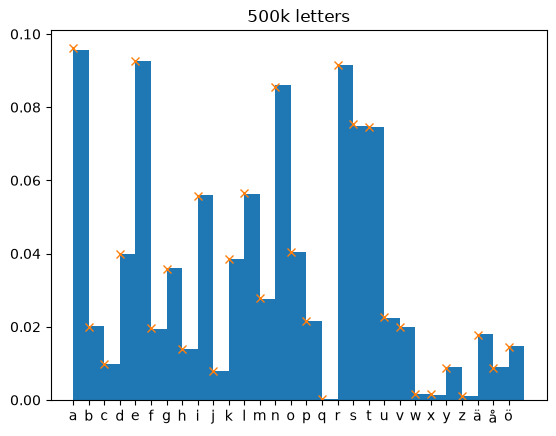

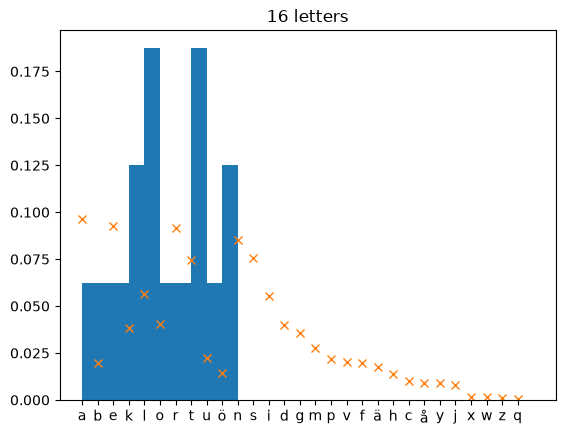

In [32]:
import numpy as np
import bisect
from pandas import Index
import pylab as plt

words = applicable_words
for key, limit in max_limits.items():
    words = words.loc[words[key] <= limit]

stats = words.loc[:,vowels[0]:consonants[-1]].describe()
stats = stats.T.sort_values(by = 'mean', ascending = False).T
stats = stats.T['mean'] / stats.T['mean'].sum()

intervals = stats.copy()

for i in range(1, len(intervals)):
    intervals.iloc[i] += intervals.iloc[i - 1]

generate_letters = lambda size: list([intervals.index[i] for i in np.searchsorted(intervals, np.random.uniform(size = size))])

sample500k = sorted(generate_letters(500000))
sample16 = sorted(generate_letters(16))

plt.figure("500k letters")
plt.hist(sample500k, bins = range(len(alphabet) + 1), density = True)
plt.plot(stats.index, stats, 'x')
plt.title("500k letters")

plt.figure("16 letters")
plt.hist(sample16, bins = range(len(alphabet) + 1), density = True)
plt.plot(stats.index, stats, 'x')
plt.title("16 letters")


## Vowel/consonant ratio
If you'll run the previous cell several times and observe the set of generated lettters after each run, you'll see that half+ of the sample are vowels. Let's try checking what the ratio would be for the set of words we have.

In [33]:
import re

for letter_set in [vowels, consonants]:
    pattern = re.compile('[{0}]'.format(letter_set))
    applicable_words[letter_set] = applicable_words.apply(lambda row: len(pattern.findall(row['words'])), axis = 1)

In [34]:
print(applicable_words.loc[:,vowels:consonants].describe())
print(applicable_words.loc[applicable_words['len'] >= 10].loc[applicable_words[vowels] >= 6, 'words':vowels[-1]])
# stats16 = applicable_words.loc[applicable_words['len'] == 16].describe().loc[:,vowels[0]:consonants[-1]]
# print(stats16.T['mean'])
stats16 = applicable_words.loc[applicable_words['len'] >= 14].describe().loc[:,vowels:consonants]
print(stats16)

          aeiouyåäö  bcdfghjklmnpqrstvwxz
count  91981.000000          91981.000000
mean       3.103358              5.581881
std        1.208618              2.083375
min        0.000000              0.000000
25%        2.000000              4.000000
50%        3.000000              5.000000
75%        4.000000              7.000000
max        8.000000             12.000000
                  words  len  a  e  i  o  u  y  å  ä  ö
70         aboriginerna   12  2  1  2  1  0  0  0  0  0
71        aboriginernas   13  2  1  2  1  0  0  0  0  0
79     abortmotståndare   16  2  1  0  2  0  0  1  0  0
108    abstraktionsnivå   16  2  0  2  1  0  0  1  0  0
121        acceleration   12  2  2  1  1  0  0  0  0  0
...                 ...  ... .. .. .. .. .. .. .. .. ..
91946    överväldigades   14  1  2  1  0  0  0  0  1  1
91947    överväldigande   14  1  2  1  0  0  0  0  1  1
91951     övervärderade   13  1  3  0  0  0  0  0  1  1
91955      överåklagare   12  2  2  0  0  0  0  1  0  1
91956 

It seems interesting to use statistics of long words as a base for reasonable limits on vowels/consonants ratio. The rationale is that there can likely be only few 16-letter words on the field, and it would definitely be cool to come up with at least one given such a chance. After playing around with this data for some time I decided to just limit the maximal number of vowels to 8, and minimal number of vowels to 3. So the algorithm would be to ~generate 3 vowels based on the statistics of long words (14+ letters), and then~ generate ~the rest~ 13 letters using the full statistics for the full set of letters, and if there are still less than 3 vowels, generate 3 more vowels using the statistics for the long words. Individual limits for the specific letters should still be controlled, so when some letter hits its limit the idea is to pop it out of the set of letters and redistribute all remaining letters evenly.

## Unique letters
Now let's take a look at the distribution of unique letters

In [44]:
applicable_words['len_uniq'] = applicable_words.apply(lambda row: len({*row['words']}), axis = 1)
words_with_repetitive_letters = applicable_words.loc[applicable_words['len_uniq'] != applicable_words['len']]

words_with_repetitive_letters.describe()

,len,a,e,i,o,u,y,å,ä,ö,...,r,s,t,v,w,x,z,aeiouyåäö,bcdfghjklmnpqrstvwxz,len_uniq
count,68832.000000,68832.000000,68832.000000,68832.000000,68832.000000,68832.000000,68832.000000,68832.000000,68832.000000,68832.000000,...,68832.000000,68832.000000,68832.000000,68832.000000,68832.000000,68832.000000,68832.000000,68832.000000,68832.000000,68832.000000
mean,9.559420,0.934987,0.926328,0.530306,0.373562,0.203597,0.072742,0.075314,0.162250,0.128748,...,0.895252,0.732828,0.750581,0.181849,0.010504,0.012727,0.007889,3.407834,6.151586,7.339188
std,2.802028,0.852898,0.876747,0.708516,0.614787,0.450170,0.265742,0.277006,0.392095,0.358231,...,0.835331,0.803451,0.862063,0.420190,0.104622,0.112481,0.100030,1.170450,1.978999,2.041897
min,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,5.000000,6.000000
50%,9.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,6.000000,7.000000
75%,11.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,4.000000,7.000000,9.000000
max,16.000000,5.000000,6.000000,5.000000,5.000000,4.000000,3.000000,3.000000,3.000000,3.000000,...,5.000000,5.000000,6.000000,3.000000,2.000000,2.000000,2.000000,8.000000,12.000000,15.000000


,len,a,e,i,o,u,y,å,ä,ö,...,r,s,t,v,w,x,z,aeiouyåäö,bcdfghjklmnpqrstvwxz,len_uniq
count,5469.000000,5469.000000,5469.000000,5469.000000,5469.000000,5469.000000,5469.000000,5469.000000,5469.000000,5469.000000,...,5469.000000,5469.000000,5469.000000,5469.000000,5469.000000,5469.000000,5469.000000,5469.000000,5469.000000,5469.000000
mean,5.106418,0.745657,0.452368,0.219236,0.238069,0.098007,0.059426,0.039312,0.053392,0.046626,...,0.393491,0.413787,0.422564,0.088133,0.017736,0.007314,0.016456,1.952094,3.154324,3.663741
std,0.949922,0.890617,0.752081,0.519224,0.560207,0.327777,0.242551,0.223258,0.233610,0.233101,...,0.690516,0.728081,0.792297,0.326113,0.137434,0.091428,0.154498,0.647635,0.825675,0.565501
min,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000,3.000000
50%,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000,4.000000
75%,6.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,4.000000,4.000000
max,11.000000,4.000000,4.000000,4.000000,4.000000,3.000000,2.000000,3.000000,2.000000,2.000000,...,4.000000,4.000000,5.000000,3.000000,2.000000,2.000000,2.000000,5.000000,7.000000,4.000000


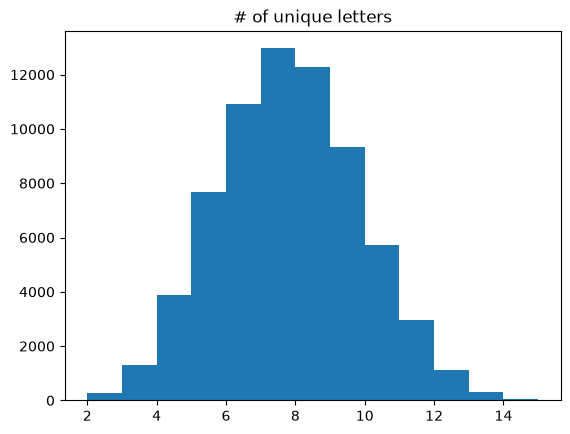

In [53]:
plt.figure("# of unique letters")
plt.hist(words_with_repetitive_letters['len_uniq'], bins = range(2,16))
plt.title("# of unique letters")
words_with_repetitive_letters.loc[words_with_repetitive_letters['len_uniq'] < 5].describe()

It looks like 6 is still a reasonable minimal limit for the number of unique letters

## Statistics of vowels in longer words
Now let's find similarly basic function for statistics of vowels in longer words.

e    0.281975
a    0.234237
i    0.186279
o    0.113055
u    0.058490
ä    0.052133
ö    0.037372
å    0.021229
y    0.015231
Name: mean, dtype: float64


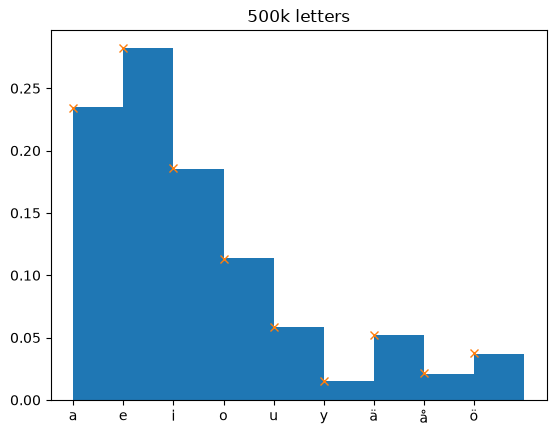

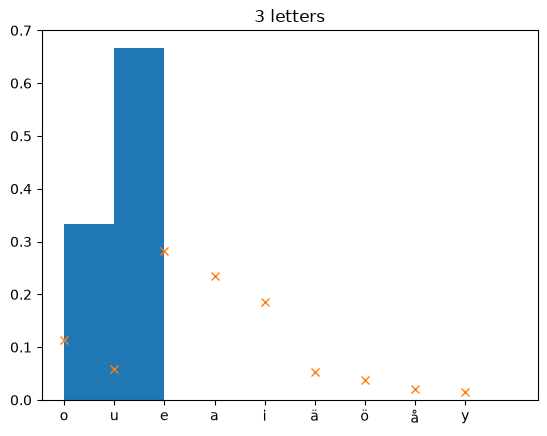

In [54]:
stats_vowels = applicable_words.loc[applicable_words['len'] > 13, vowels[0]:vowels[-1]].describe()
stats_vowels = stats_vowels.T.sort_values(by = 'mean', ascending = False).T
stats_vowels = stats_vowels.T['mean'] / stats_vowels.T['mean'].sum()

intervals_vowels = stats_vowels.copy()

for i in range(1, len(intervals_vowels)):
    intervals_vowels.iloc[i] += intervals_vowels.iloc[i - 1]

generate_vowels = lambda size: list([intervals_vowels.index[i] for i in np.searchsorted(intervals_vowels, np.random.uniform(size = size))])

sample500k = sorted(generate_vowels(500000))
sample16 = sorted(generate_vowels(3))

plt.figure("500k letters")
plt.hist(sample500k, bins = range(len(vowels) + 1), density = True)
plt.plot(stats_vowels.index, stats_vowels, 'x')
plt.title("500k letters")

plt.figure("3 letters")
plt.hist(sample16, bins = range(len(vowels) + 1), density = True)
plt.plot(stats_vowels.index, stats_vowels, 'x')
plt.title("3 letters")

print(stats_vowels)

## Implementation
Finally we can get to the actual implementation of the algorithm.

In [71]:
import pandas as pd
from functools import reduce

print(max_limits)

# source: https://ncm.gu.se/media/namnaren/kryptoskola/24_Krypto2_Sprak2.pdf
freqs = {
    'a': 9.0,
    'b': 1.3,
    'c': 1.2,
    'd': 4.8,
    'e': 10.1,
    'f': 1.9,
    'g': 3.0,
    'h': 1.9,
    'i': 6.2,
    'j': 0.6,
    'k': 3.4,
    'l': 5.0,
    'm': 3.4,
    'n': 8.6,
    'o': 4.4,
    'p': 1.8,
    'q': 0.01, # NOTE: there was literally zero at the source!
    'r': 8.7,
    's': 6.9,
    't': 8.2,
    'u': 1.8,
    'v': 2.5,
    'w': 0.1,
    'x': 0.1,
    'y': 0.5,
    'z': 0.01,
    'å': 1.3,
    'ä': 1.7,
    'ö': 1.5
}

f_stats = pd.Series(freqs)

def get_intervals(statistics):
    ret = statistics / statistics.sum()
    for i in range(1, len(ret)):
        ret.iloc[i] += ret.iloc[i-1]
    return ret

def get_ix(letter):
    if (ord(letter) <= ord('z')):
        return ord(letter) - ord('a')
    if (letter == 'å'):
        return 26
    elif (letter == 'ä'):
        return 27
    elif (letter == 'ö'):
        return 28

    raise Exception("Invalid letter {}".format(letter))

def get_ch(ix):
    if (ix < 26):
        return chr(ix + ord('a'))
    elif (ix == 26):
        return 'å'
    elif (ix == 27):
        return 'ä'
    elif (ix == 28):
        return 'ö'

    raise Exception("Invalid index {}".format(ix))

class FieldGenerator:
    def __init__(self):
        self.limits = {**max_limits}
        self.stats_common = f_stats.copy()
        self.stats_vowels = stats_vowels.copy()

        self.field = None
        self.freq_map = np.zeros(29, dtype = int)
    
    def get_field(self):
        if self.field is None:
            self._generate()

        return self.field
    
    def _generate(self):
        self.field = []
        sample = np.random.uniform(size = 16)
        stts = self.stats_common
        intervals_ = get_intervals(stts)
        for i in range(len(sample)):
            letter = intervals_.index[np.searchsorted(intervals_, sample[i])]
            self.freq_map[get_ix(letter)] += 1
            freq = self.freq_map[get_ix(letter)]
            if (freq == max_limits[letter]):
                stts = stts.drop(labels = (letter))
                if letter in self.stats_vowels.index and not stts is self.stats_vowels:
                    self.stats_vowels = self.stats_vowels.drop(labels = (letter))
                intervals_ = get_intervals(stts)
                print("Dropping letter {0}".format(letter))
            if (i >= len(sample) - 4) and not stts is self.stats_vowels:
                total_vowels = 0
                for vowel in vowels:
                    total_vowels += self.freq_map[get_ix(vowel)]
                if total_vowels < 3:
                    stts = self.stats_vowels
                    intervals_ = get_intervals(stts)
            print("Generated value {0}, letter {1}, freq map {2}".format(sample[i], letter, self.freq_map))
            self.field.append(letter)

field = FieldGenerator()
print(sorted(field.get_field()))

print("Unique letters: {0}, vowels: {1}, consonants: {2}".format(len(set(field.get_field())),
                                                                reduce(lambda res, char: res + vowels.count(char), field.get_field(), 0),
                                                                reduce(lambda res, char: res + consonants.count(char), field.get_field(), 0)))

solution = applicable_words
for code, freq in enumerate(field.freq_map):
    letter = get_ch(code)
    solution = solution.loc[solution[letter] <= freq]
print(solution.describe())
print(solution)

{'a': np.float64(3.0), 'e': np.float64(3.0), 'i': np.float64(3.0), 'o': np.float64(3.0), 'u': np.float64(2.0), 'y': np.float64(2.0), 'å': np.float64(2.0), 'ä': np.float64(2.0), 'ö': np.float64(2.0), 'b': np.float64(2.0), 'c': np.float64(2.0), 'd': np.float64(2.0), 'f': np.float64(2.0), 'g': np.float64(3.0), 'h': np.float64(2.0), 'j': np.float64(2.0), 'k': np.float64(2.0), 'l': np.float64(3.0), 'm': np.float64(2.0), 'n': np.float64(4.0), 'p': np.float64(3.0), 'q': np.float64(1.0), 'r': np.float64(3.0), 's': np.float64(3.0), 't': np.float64(3.0), 'v': np.float64(2.0), 'w': np.float64(2.0), 'x': np.float64(1.0), 'z': np.float64(2.0)}
Generated value 0.8578666949331378, letter t, freq map [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
Generated value 0.2599055274601554, letter e, freq map [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
Generated value 0.6889930692982835, letter r, freq map [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0]
Generated value 